# `campaign2_all.db` — environment channels, robustness follow-up

**Why this notebook exists.** In `data_exploration.ipynb`, cell 46 reported a permutation
test showing that `Humidity_in`, `DMF_ppm_out` and `Temperature_in` carry conditional
mutual information (CMI) about the `Objective` of ~0.10 nats that *survives* conditioning
on composition + wall-clock time + BO iteration ($Z_\text{full}$), each at $p=0.010$.

That is genuine evidence of an association beyond campaign drift, but the original cell has
three weaknesses that stop it short of the "we should control humidity/DMF in hardware"
conclusion. This notebook addresses each:

1. **The $p=0.010$ is the permutation floor.** With 100 permutations the smallest achievable
   $p$ is $1/101\approx0.0099$, so "0.010" just means *no* permutation beat the observed value —
   we can't resolve how significant it is. → **Rerun with 500 permutations.**
2. **Post-selection bias (winner's curse).** Cell 46 ranked all scalars by CMI then tested only
   the top 4. Testing the winners inflates significance. → **Test *all 8* environment channels
   and apply a Benjamini–Hochberg FDR correction.**
3. **The environment channels co-drift and may be mutually redundant.** Temperature, humidity
   and DMF are all glovebox state and mutually correlated; conditioning on composition/time does
   not separate them *from each other*. → **Measure their mutual correlation, then test whether
   each survives conditioning on the *other* environment channels (unique contribution).**

Finally we put the effect **on a scale** (vs the definitional sub-targets) and discuss what the
data fundamentally *cannot* tell us — process effect vs measurement artifact, and causal direction.

> This notebook is self-contained: it reloads the DB and re-defines the KSG/Frenzel–Pompe
> estimator so it can be run independently of `data_exploration.ipynb`.

In [2]:
import sqlite3, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import digamma
from scipy.spatial import cKDTree

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
DB = "data/campaign2_all.db"

df = pd.read_sql("select * from results", sqlite3.connect(DB))

# wall-clock time as seconds since the campaign start (Timestamp is stored as text)
_t = pd.to_datetime(df["Timestamp"])
df["_time_sec"] = (_t - _t.min()).dt.total_seconds()

ENV = ["Temperature_in", "Temperature_out", "Humidity_in", "Humidity_out",
       "Pressure_in", "Pressure_out", "DMF_ppm_in", "DMF_ppm_out"]

OBJ       = df["Objective"].values
COND_COMP = df[["FAPbI3", "MAPbBr3"]].values                            # composition only
COND_FULL = df[["FAPbI3", "MAPbBr3", "_time_sec", "Iteration"]].values  # + time + iteration

print("rows:", len(df),
      " | campaign hours:", round(df['_time_sec'].max()/3600, 1),
      " | rows with an Objective:", int(np.isfinite(OBJ).sum()))

rows: 953  | campaign hours: 54.3  | rows with an Objective: 644


## 1 · The estimator (unchanged from `data_exploration.ipynb`)

KSG / Frenzel–Pompe kNN estimate of $I(X;Y\mid Z)$ in nats, plus the local-permutation
p-value that shuffles $X$ **within $Z$-neighbourhoods** so it preserves $I(X;Z)$ but breaks
$I(X;Y\mid Z)$. `cmi_cond` is a small generalisation that lets us append extra columns to the
conditioning set (used later for the attribution test).

In [3]:
def _as_col(a):
    a = np.asarray(a, float)
    return a.reshape(-1, 1) if a.ndim == 1 else a

def _standardize(a):
    s = a.std(0); s[s == 0] = 1.0
    return (a - a.mean(0)) / s

def cmi_ksg(X, Y, Z, k=5):
    '''KSG/Frenzel-Pompe estimate of I(X;Y|Z) in nats (>=0).'''
    X, Y, Z = _standardize(_as_col(X)), _standardize(_as_col(Y)), _standardize(_as_col(Z))
    n = len(X)
    XYZ = np.hstack([X, Y, Z]); XZ = np.hstack([X, Z]); YZ = np.hstack([Y, Z])
    eps = cKDTree(XYZ).query(XYZ, k=k + 1, p=np.inf)[0][:, -1]
    def _count(A):
        t = cKDTree(A)
        return np.fromiter((len(t.query_ball_point(A[i], eps[i] - 1e-12, p=np.inf)) - 1
                            for i in range(n)), dtype=float, count=n)
    val = digamma(k) + np.mean(digamma(_count(Z) + 1)
                               - digamma(_count(XZ) + 1) - digamma(_count(YZ) + 1))
    return max(float(val), 0.0)

def cmi_pvalue(X, Y, Z, k=5, n_perm=500, seed=1):
    '''Local-permutation p-value: shuffle X among Z-neighbours (preserves I(X;Z)).'''
    X, Y, Z = _as_col(X), _as_col(Y), _as_col(Z)
    obs = cmi_ksg(X, Y, Z, k)
    r = np.random.default_rng(seed)
    nbrs = cKDTree(_standardize(Z)).query(_standardize(Z), k=min(10, len(X)))[1]
    null = np.empty(n_perm)
    for p in range(n_perm):
        perm = np.arange(len(X))
        for i in r.permutation(len(X)):
            j = nbrs[i, r.integers(nbrs.shape[1])]
            perm[i], perm[j] = perm[j], perm[i]
        null[p] = cmi_ksg(X[perm], Y, Z, k)
    return obs, (1 + np.sum(null >= obs)) / (1 + n_perm), null

def _finite_mask(x, *extra):
    m = np.isfinite(x) & np.isfinite(OBJ) & np.isfinite(COND_FULL).all(1)
    for e in extra:
        m &= np.isfinite(e).all(1)
    return m

def cmi_cond(feat, extra=None, k=5):
    '''CMI(Objective ; feat | composition, time, iteration [, extra cols]) on shared finite rows.'''
    x = np.asarray(feat, float)
    extra_arr = np.asarray(extra, float).reshape(len(x), -1) if extra is not None else None
    m = _finite_mask(x) if extra_arr is None else _finite_mask(x, extra_arr)
    Z = COND_FULL[m] if extra_arr is None else np.hstack([COND_FULL[m], extra_arr[m]])
    return cmi_ksg(x[m], OBJ[m], Z, k), int(m.sum())

def bh_fdr(pvals):
    '''Benjamini-Hochberg adjusted p-values (q-values).'''
    p = np.asarray(pvals, float); n = len(p)
    order = np.argsort(p); ranked = p[order] * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(ranked[::-1])[::-1]
    out = np.empty(n); out[order] = np.clip(q, 0, 1)
    return out

# --- "conditional Pearson" for comparison ---------------------------------
# Partial correlation of Objective vs a feature, conditioning on the SAME
# Z_full (composition + time + iteration) the CMI uses, by linearly
# residualising both sides on Z and correlating the residuals. This is the
# fixed-scale [-1, 1] linear analogue of the CMI. `method="spearman"` first
# rank-transforms every variable, so it captures monotonic (but still not
# non-monotonic) dependence while staying on the same scale.
def partial_corr(feat, method="pearson"):
    '''Partial corr of Objective vs feat | (composition, time, iteration).'''
    x = np.asarray(feat, float)
    m = _finite_mask(x)
    xm, ym, Zm = x[m], OBJ[m], COND_FULL[m]
    if method == "spearman":
        from scipy.stats import rankdata
        xm, ym = rankdata(xm), rankdata(ym)
        Zm = np.column_stack([rankdata(Zm[:, j]) for j in range(Zm.shape[1])])
    A = np.hstack([np.ones((len(xm), 1)), Zm])
    resid = lambda v: v - A @ np.linalg.lstsq(A, v, rcond=None)[0]
    return float(np.corrcoef(resid(xm), resid(ym))[0, 1]), int(m.sum())

def cmi_to_rho(cmi):
    '''Information-implied correlation rho = sqrt(1 - exp(-2*I)): the Pearson
    rho a jointly-Gaussian pair would need to carry `cmi` nats. Puts CMI on
    the same familiar [0, 1] scale as |partial_r| (exact under Gaussianity,
    a monotone rescaling otherwise).'''
    return np.sqrt(1.0 - np.exp(-2.0 * np.asarray(cmi, float)))

print("estimator + helpers ready")

estimator + helpers ready


## 2 · Fixes 1 & 2 — all 8 environment channels, 500 permutations, FDR-corrected

For every environment channel we compute CMI under composition-only ($Z_\text{comp}$) and under
$Z_\text{full}$, then a 500-permutation p-value under $Z_\text{full}$. Because we now test all 8
channels, raw p-values are corrected with Benjamini–Hochberg (`q_value`). The column `confound`
$=\text{CMI}_\text{comp}-\text{CMI}_\text{full}$ is how much of the raw signal was just campaign drift.

In [4]:
records = []
for f in ENV:
    x = df[f].values
    m = _finite_mask(x)
    if m.sum() < 50:
        continue
    c_comp = cmi_ksg(x[m], OBJ[m], COND_COMP[m], k=5)
    obs, p, _ = cmi_pvalue(x[m], OBJ[m], COND_FULL[m], k=5, n_perm=500, seed=1)
    pr, _  = partial_corr(x)                     # conditional Pearson  | Z_full
    prs, _ = partial_corr(x, method="spearman")  # conditional Spearman | Z_full
    records.append({"feature": f, "n": int(m.sum()),
                    "cmi_comp": c_comp, "cmi_full": obs,
                    "confound": c_comp - obs, "p_raw": p,
                    "partial_r": pr, "partial_r_spm": prs})

env_cmi = pd.DataFrame(records)
env_cmi["q_value"] = bh_fdr(env_cmi["p_raw"].values)
env_cmi["rho_equiv"] = cmi_to_rho(env_cmi["cmi_full"])   # CMI on the |partial_r| scale
env_cmi["sig_FDR5%"] = np.where(env_cmi["q_value"] < 0.05, "*", "")
env_cmi = env_cmi.sort_values("cmi_full", ascending=False).reset_index(drop=True)

# column order: information view, then the fixed-scale linear/monotonic view
env_cmi[["feature", "n", "cmi_comp", "cmi_full", "confound", "p_raw", "q_value",
         "sig_FDR5%", "rho_equiv", "partial_r", "partial_r_spm"]].round(4)

,feature,n,cmi_comp,cmi_full,confound,p_raw,q_value,sig_FDR5%,rho_equiv,partial_r,partial_r_spm
0,Humidity_in,644,0.1257,0.1071,0.0186,0.0020,0.0160,*,0.4392,-0.0342,-0.0286
1,DMF_ppm_out,644,0.1132,0.1047,0.0084,0.0060,0.0213,*,0.4347,0.1993,0.2129
2,Temperature_in,644,0.1129,0.0993,0.0136,0.0080,0.0213,*,0.4244,0.1004,0.1059
3,DMF_ppm_in,644,0.1033,0.0727,0.0306,0.1337,0.2675,,0.3679,0.1440,0.1983
4,Temperature_out,644,0.1151,0.0568,0.0583,0.2036,0.3257,,0.3278,-0.0620,0.1406
5,Humidity_out,644,0.1272,0.0500,0.0772,0.9441,0.9441,,0.3084,0.1449,0.0714
6,Pressure_in,644,0.0539,0.0317,0.0222,0.3792,0.5057,,0.2479,0.2373,-0.0895
7,Pressure_out,644,0.0609,0.0317,0.0292,0.4990,0.5703,,0.2479,0.2435,-0.0509


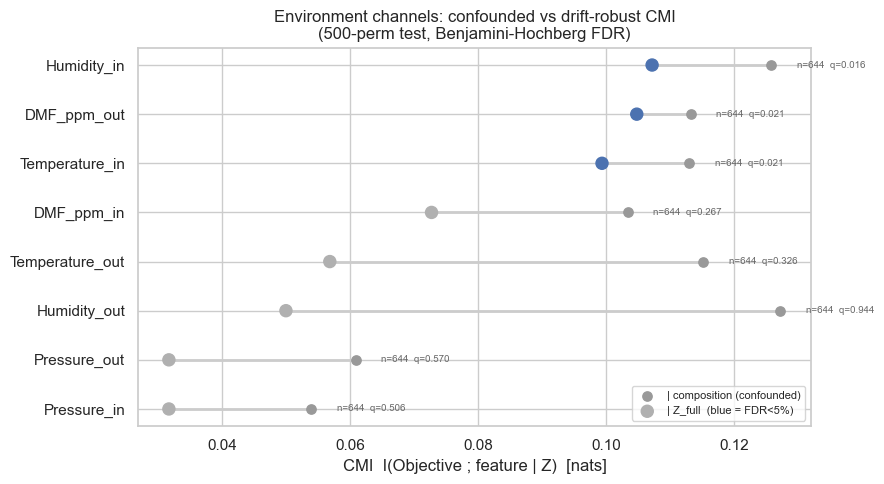

In [5]:
# Confound view for all 8 channels, coloured by FDR significance
m = env_cmi.sort_values("cmi_full")
fig, ax = plt.subplots(figsize=(9, 5))
ypos = np.arange(len(m))
colors = np.where(m["q_value"].values < 0.05, "#4c72b0", "#b0b0b0")
ax.hlines(ypos, m["cmi_full"], m["cmi_comp"], color="0.8", lw=2, zorder=1)
ax.scatter(m["cmi_comp"], ypos, color="0.6", s=45, label="| composition (confounded)", zorder=2)
ax.scatter(m["cmi_full"], ypos, color=colors, s=75, zorder=3,
           label="| Z_full  (blue = FDR<5%)")
ax.set_yticks(ypos); ax.set_yticklabels(m["feature"])
for i, (_, r) in enumerate(m.iterrows()):
    ax.text(max(r["cmi_comp"], r["cmi_full"]) + 0.004, i,
            f"n={r['n']}  q={r['q_value']:.3f}", va="center", fontsize=7, color="0.4")
ax.set_xlabel("CMI  I(Objective ; feature | Z)  [nats]")
ax.set_title("Environment channels: confounded vs drift-robust CMI\n(500-perm test, Benjamini-Hochberg FDR)")
ax.legend(fontsize=8, loc="lower right"); plt.tight_layout(); plt.show()

### CMI vs the "conditional Pearson" — why the choice of estimator matters here

`partial_r` is the literal linear analogue of the CMI: Objective and the channel are each
regressed on the *same* $Z_\text{full}$ (composition + time + iteration) and the residuals
correlated, so it lives on the fixed $[-1,1]$ scale. `partial_r_spm` does the same on ranks
(monotonic). `rho_equiv` $=\sqrt{1-e^{-2\,\text{CMI}}}$ puts the CMI on that same scale.
Reading the three side by side is exactly why this notebook uses CMI rather than partial
correlation:

- **`Humidity_in` — CMI's headline channel, invisible to Pearson.** `rho_equiv`$\approx0.44$
  yet `partial_r`$\approx-0.03$ *and* `partial_r_spm`$\approx-0.03$. Near-zero linear **and**
  monotonic correlation with a large CMI is the signature of a **non-monotonic** effect (a
  threshold / optimum). A partial-correlation screen would have thrown this channel out.
- **`Pressure_in` / `Pressure_out` — a Pearson false positive.** `partial_r`$\approx+0.24$
  looks like the strongest linear signal in the table, but `partial_r_spm`$\approx-0.05$ (sign
  flips) and the CMI is low and *not* FDR-significant. That divergence is the fingerprint of a
  few high-leverage points, not a real dependence — precisely the trap a fixed-scale linear
  coefficient walks into.
- **`DMF_ppm_out` — everyone agrees.** CMI significant, `partial_r`$\approx+0.20$,
  `partial_r_spm`$\approx+0.21$: a genuine, largely monotonic association. When the effect *is*
  monotonic, the two estimators land in the same place.

**Takeaway.** Where CMI and $|$partial_r$|$ agree (DMF), you get the interpretable Pearson scale
for free. Where they disagree, CMI is the one to trust: it catches the non-monotonic real signal
(humidity) that Pearson misses and ignores the leverage-driven artifact (pressure) that Pearson
flags. The fixed scale you like is recovered via `rho_equiv` without giving up that robustness.

## 3 · Fix 3a — how tightly do the environment channels co-drift?

If Temperature / Humidity / DMF are strongly correlated with each other, then an individual
"CMI given $Z_\text{full}$" cannot be attributed to that specific channel — each is partly a proxy
for a shared glovebox state. Spearman correlation among the channels (on rows where the objective
is present):

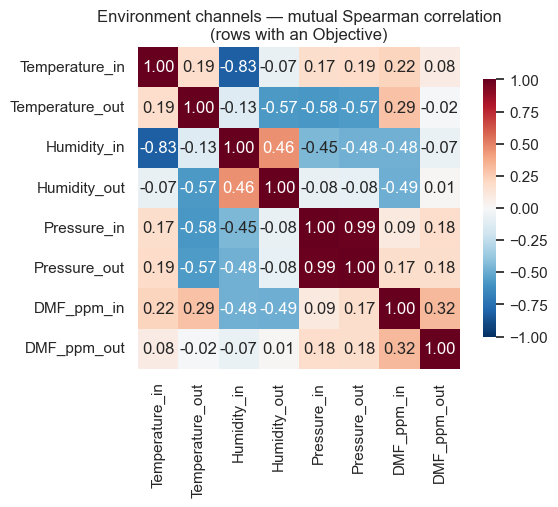

In [6]:
env_present = df.loc[np.isfinite(OBJ), ENV]
env_corr = env_present.corr("spearman")
plt.figure(figsize=(6.4, 5.2))
sns.heatmap(env_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8})
plt.title("Environment channels — mutual Spearman correlation\n(rows with an Objective)")
plt.tight_layout(); plt.show()

## 4 · Fix 3b — unique contribution: does each channel survive conditioning on the others?

The decisive attribution test. For each significant channel $A$ we compute
$I(\text{Objective}; A \mid Z_\text{full}, B)$ for every other channel $B$: if $A$'s CMI collapses
toward 0 once we also condition on $B$, then $A$ was largely a proxy for $B$ and they are **not
separable**. The diagonal is the marginal $I(\text{Objective}; A \mid Z_\text{full})$ for reference.

> **Caveat — dimensionality.** Adding a channel pushes the KSG conditioning set to 5 dimensions
> (7-dim joint) at n≈644. KSG estimates get noisier and biased low as dimension grows, so read the
> off-diagonals as *directional evidence of redundancy*, not precise numbers. A drop from ~0.10 to
> near 0 is meaningful; small wiggles are not.

In [7]:
# focus on the channels that were individually significant under FDR
sig_channels = env_cmi.loc[env_cmi["q_value"] < 0.05, "feature"].tolist()
focus = sig_channels if len(sig_channels) >= 2 else env_cmi["feature"].head(3).tolist()
print("attribution grid over:", focus)

grid = pd.DataFrame(index=focus, columns=["marginal"] + focus, dtype=float)
for a in focus:
    grid.loc[a, "marginal"], _ = cmi_cond(df[a].values)          # I(O;A | Z_full)
    for b in focus:
        if a == b:
            grid.loc[a, b] = np.nan
        else:
            grid.loc[a, b], _ = cmi_cond(df[a].values, extra=df[b].values)  # I(O;A | Z_full, B)
grid.round(4)

attribution grid over: ['Humidity_in', 'DMF_ppm_out', 'Temperature_in']


,marginal,Humidity_in,DMF_ppm_out,Temperature_in
Humidity_in,0.1071,NaN,0.0632,0.0817
DMF_ppm_out,0.1047,0.0645,NaN,0.0832
Temperature_in,0.0993,0.0590,0.0603,NaN


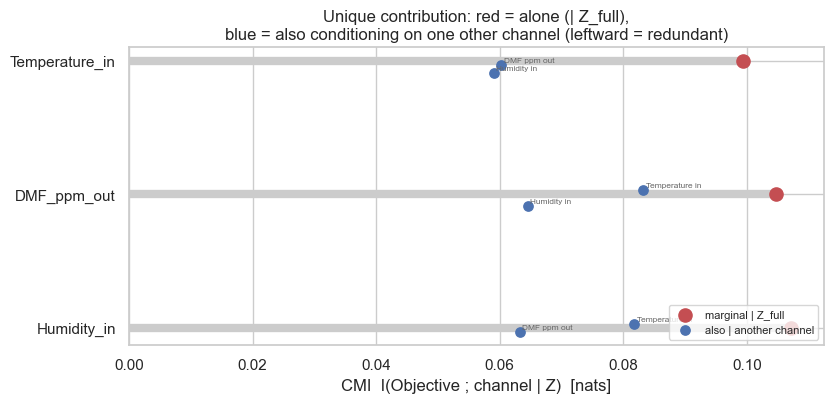

In [8]:
# Visualise the attribution grid: marginal bar + conditioned-on-each-other points
fig, ax = plt.subplots(figsize=(8.5, 0.9 * len(focus) + 1.5))
ypos = np.arange(len(focus))
for i, a in enumerate(focus):
    marg = grid.loc[a, "marginal"]
    ax.plot([0, marg], [i, i], color="0.8", lw=6, solid_capstyle="round", zorder=1)
    ax.scatter(marg, i, color="#c44e52", s=90, zorder=3, label="marginal | Z_full" if i == 0 else "")
    for j, b in enumerate(focus):
        if a == b:
            continue
        ax.scatter(grid.loc[a, b], i + (j - len(focus)/2) * 0.06, s=45, color="#4c72b0",
                   zorder=2, label="also | another channel" if (i == 0 and j == 1) else "")
        ax.annotate(b.replace("_", " "), (grid.loc[a, b], i + (j - len(focus)/2) * 0.06),
                    fontsize=6, color="0.4", xytext=(2, 2), textcoords="offset points")
ax.set_yticks(ypos); ax.set_yticklabels(focus)
ax.set_xlabel("CMI  I(Objective ; channel | Z)  [nats]")
ax.set_title("Unique contribution: red = alone (| Z_full),\nblue = also conditioning on one other channel (leftward = redundant)")
ax.legend(fontsize=8, loc="lower right"); ax.set_xlim(left=0)
plt.tight_layout(); plt.show()

## 5 · Putting the effect on a scale

0.10 nats is only meaningful relative to something. The `Objective` is a deterministic function
of `Bandgap`, `Photoconductance` and `Stability`, so those three set the ceiling of what
"strongly informative given composition" looks like with this estimator and sample size. We report
the environment channels as a fraction of that ceiling (they turn out **comparable to `Bandgap` and `Stability`**, so "small" holds only relative to `Photoconductance`), and also convert to **bits** ($\div\ln 2$).

In [9]:
ref_feats = ["Photoconductance", "Bandgap", "Stability"]
scale_rows = []
for f in ref_feats:
    c, n = cmi_cond(df[f].values)
    pr, _ = partial_corr(df[f].values)
    scale_rows.append({"feature": f, "kind": "sub-target (definitional)",
                       "cmi_full": c, "n": n, "partial_r": pr})
for _, r in env_cmi.iterrows():
    scale_rows.append({"feature": r["feature"], "kind": "environment",
                       "cmi_full": r["cmi_full"], "n": r["n"], "partial_r": r["partial_r"]})
scale = pd.DataFrame(scale_rows)
ceiling = scale.loc[scale.feature == "Photoconductance", "cmi_full"].iloc[0]
scale["bits"] = scale["cmi_full"] / np.log(2)
scale["rho_equiv"] = cmi_to_rho(scale["cmi_full"])         # CMI on the |partial_r| scale
scale["% of Photoconductance"] = 100 * scale["cmi_full"] / ceiling
scale.sort_values("cmi_full", ascending=False).round(3).reset_index(drop=True)

,feature,kind,cmi_full,n,partial_r,bits,rho_equiv,% of Photoconductance
0,Photoconductance,sub-target (definitional),0.427,644,0.727,0.616,0.758,100.000
1,Bandgap,sub-target (definitional),0.156,644,-0.551,0.225,0.518,36.573
2,Stability,sub-target (definitional),0.119,644,0.242,0.172,0.461,27.987
3,Humidity_in,environment,0.107,644,-0.034,0.155,0.439,25.112
4,DMF_ppm_out,environment,0.105,644,0.199,0.151,0.435,24.551
5,Temperature_in,environment,0.099,644,0.100,0.143,0.424,23.279
6,DMF_ppm_in,environment,0.073,644,0.144,0.105,0.368,17.041
7,Temperature_out,environment,0.057,644,-0.062,0.082,0.328,13.319
8,Humidity_out,environment,0.050,644,0.145,0.072,0.308,11.714
9,Pressure_in,environment,0.032,644,0.237,0.046,0.248,7.431


## 6 · What the data can and cannot tell us

**What these results establish (statistically):**

- Whether the environment→objective association survives drift is now tested on *all* channels
  with a resolvable p-value (500 perms) and an FDR correction — see the `q_value` column and which
  channels stay blue in §2. That removes the winner's-curse and permutation-floor objections.
- The correlation heatmap (§3) and attribution grid (§4) show **how much of each channel's signal
  is unique** vs shared glovebox state — i.e. whether we can even say "humidity" rather than "the
  environment" is the driver.
- §5 shows the **magnitude relative to the definitional sub-targets** — environment CMI (~0.10 nats) is ~25% of
  `Photoconductance` but on par with `Bandgap` (0.156) and `Stability` (0.119) — modest but not negligible.

**What no amount of this analysis can establish** — and why the hardware conclusion needs more:

1. **Direction / causality.** CMI is symmetric and observational. A surviving association is
   consistent with humidity→film, but cannot rule out a common cause not captured by time+iteration
   (reagent age, batch, operator, spot position).
2. **Process effect vs measurement artifact.** The signal could mean the environment changed the
   *film itself* (control it → better yield/reproducibility) **or** perturbed the *readout* of the
   objective (control it → cleaner measurement). These need different fixes and the data cannot
   distinguish them.

**Bottom line.** This is strong, drift-robust, multiplicity-corrected, *hypothesis-generating*
evidence that glovebox environment carries real information about the objective — enough to justify
tighter humidity/DMF logging and a **deliberate controlled experiment** (fix composition, vary
humidity/DMF on purpose, watch the objective move). It is not, on its own, proof of a causal
hardware effect. The controlled experiment is what converts this association into the causal claim
a hardware decision requires.